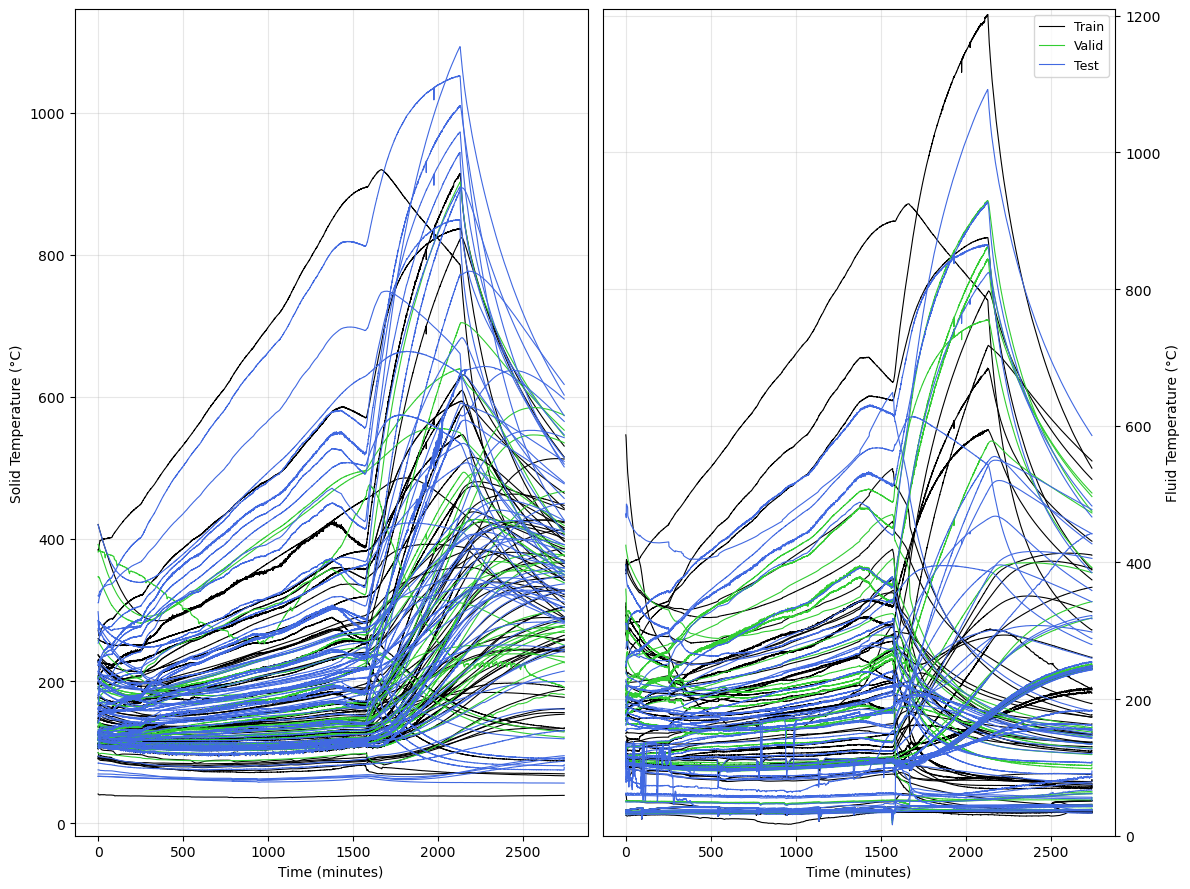

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

def plot_ts_tf_from_multiple_csvs(
    csv_paths,
    labels,
    colors,
    segment_length=5485, alpha=1.0
):
    """
    Plots TS and TF segments from multiple CSVs on two side-by-side subplots.

    Arguments:
      csv_paths      : list of file paths, e.g. ["TF_TS_train.csv", "TF_TS_valid.csv", "TF_TS_test.csv"]
      labels         : list of labels corresponding to each CSV, e.g. ["Train", "Valid", "Test"]
      colors         : list of colors for each CSV’s segments, e.g. ["red", "green", "blue"]
      segment_length : length of each smaller signal (default 5485)
    """
    fig, (ax_ts, ax_tf) = plt.subplots(ncols=2, figsize=(12,9), sharex=True)

    for csv_path, label, color in zip(csv_paths, labels, colors):
        df = pd.read_csv(csv_path)
        ts = df['TS'].to_numpy()
        tf = df['TF'].to_numpy()

        n_segments = len(ts) // segment_length
        x = np.arange(segment_length)
        x = x * (30/60)

        # Plot TS segments
        for i in range(n_segments):
            start = i * segment_length
            end = start + segment_length
            # Only label the first segment so legend doesn't repeat
            ax_ts.plot(
                x,
                ts[start:end],
                color=color,
                alpha=alpha,
                linewidth=0.8,
                label=label if i == 0 else ""
            )

        # Plot TF segments
        for i in range(n_segments):
            start = i * segment_length
            end = start + segment_length
            ax_tf.plot(
                x,
                tf[start:end],
                color=color,
                alpha=alpha,
                linewidth=0.8,
                label=label if i == 0 else ""
            )

    ax_tf.set_ylim(0,1110)
    ax_ts.set_xlabel("Time (minutes)")
    ax_ts.set_ylabel("Solid Temperature (°C)")
    #ax_ts.legend(loc='upper right', fontsize=9)
    ax_ts.grid(alpha=0.3)

    ax_tf.set_ylim(0,1210)
    ax_tf.set_xlabel("Time (minutes)")
    ax_tf.set_ylabel("Fluid Temperature (°C)")
    ax_tf.legend(loc='upper right', fontsize=9)
    ax_tf.yaxis.tick_right()
    ax_tf.yaxis.set_label_position("right")
    ax_tf.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"HTTF_viz.png", dpi=300, bbox_inches='tight')
    plt.show()


# Usage:
csv_files = ["TF_TS_train.csv", "TF_TS_valid.csv", "TF_TS_test.csv"]
labels    = ["Train", "Valid", "Test"]
colors    = ["k", "limegreen", "royalblue"]

plot_ts_tf_from_multiple_csvs(csv_files, labels, colors, alpha=1)